# COE 311K Final Project - Part 3
**Individual Project**
*   **Name:** Mitchell Blaha
*   **EID:** mrb5842

---

# Section 1: Review of Part 2

In Part 2 I got Backward Euler + Newton-Raphson working on the stiff catalase ODE $y' = -1000y + 1000(1+\sin t)$. The solver does its job, but there are two issues I want to address:

1. **Fragile root-finding.** Standard NR can diverge if the initial guess is bad or the function is highly nonlinear. My Part 2 system was linear so NR always converged in ~1 step, but that won't always be the case.
2. **Fixed step size.** I used a constant $h$ everywhere, which is wasteful — the solution changes rapidly at the start (stiff transient) and then barely changes at all (smooth sine wave). An adaptive method should take tiny steps when needed and big steps when the solution is smooth.

---

# Section 2: Damped Newton-Raphson

The fix is pretty straightforward — instead of always taking the full NR step $\Delta y = -G(y)/G'(y)$, we scale it by a damping factor $\alpha \in (0, 1]$:

$$y_{k+1} = y_k + \alpha \cdot \Delta y$$

I start with $\alpha = 1$ (full step). If the residual gets worse, I halve $\alpha$ and retry. This guarantees I always make progress toward the root.

### Demonstration
My chemical ODE from Part 2 is linear in $y$, so standard NR actually converges in one step and damping isn't strictly needed for that particular case. But to demonstrate why damping matters in general, I'll use the function $G(x) = \arctan(x)$ with $x_0 = 1.5$ as a test case. This is a well-known pathological example — the derivative $G'(x) = 1/(1+x^2)$ gets tiny for large $x$, which makes the undamped correction step blow up.

Standard NR after 10 iters: x = 2453994637498495522179279697526916057699567372002681230504971233646742496400468656445422854640968559407136768.00 — DIVERGED
Damped NR converged in 3 iters: x = -0.00000000
Alpha values used: [0.5, 1.0, 1.0]


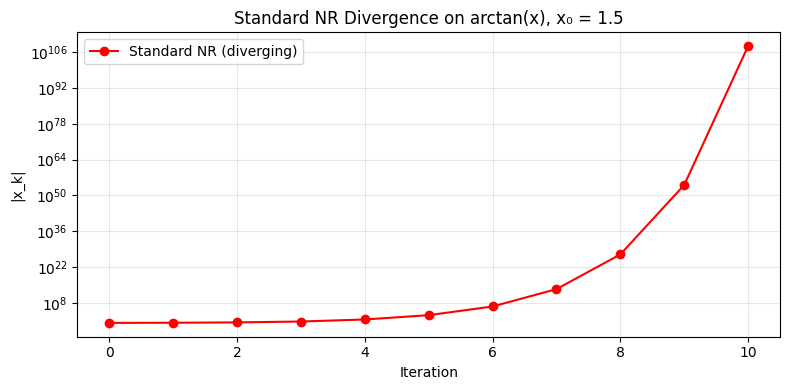

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def damped_nr(G, dG, guess, tol=1e-8, max_iter=50):
    """NR with backtracking line search. Returns (root, iters, alpha_history)."""
    y = guess
    alphas = []
    for i in range(max_iter):
        res = G(y)
        if abs(res) < tol:
            return y, i, alphas
        step = -res / dG(y)
        alpha = 1.0
        while True:
            y_try = y + alpha * step
            if abs(G(y_try)) < abs(res) or alpha < 1e-4:
                break
            alpha *= 0.5
        y = y_try
        alphas.append(alpha)
    print(f"Warning: damped NR did not converge in {max_iter} iters")
    return y, max_iter, alphas

# --- demo: arctan(x) ---
G_demo  = lambda x: np.arctan(x)
dG_demo = lambda x: 1 / (1 + x**2)

x0 = 1.5

# standard NR (force alpha=1)
x_std = x0
std_hist = [abs(x_std)]
for _ in range(10):
    x_std = x_std - G_demo(x_std)/dG_demo(x_std)
    std_hist.append(abs(x_std))

# damped NR
x_dmp, iters_dmp, alphas_dmp = damped_nr(G_demo, dG_demo, x0)

print(f"Standard NR after 10 iters: x = {x_std:.2f} — {'DIVERGED' if abs(x_std) > 10 else 'ok'}")
print(f"Damped NR converged in {iters_dmp} iters: x = {x_dmp:.8f}")
print(f"Alpha values used: {[round(a,4) for a in alphas_dmp]}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(std_hist)), std_hist, 'r-o', label='Standard NR (diverging)')
ax.set_yscale('log')
ax.set_title("Standard NR Divergence on arctan(x), x₀ = 1.5")
ax.set_xlabel("Iteration"); ax.set_ylabel("|x_k|")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The standard NR diverges immediately — the derivative $1/(1+x^2)$ is so small for large $x$ that the correction step overshoots massively, and then each subsequent iteration just makes it worse. Damped NR catches this by checking whether the residual actually decreased after each step. When it didn't (first iteration), it halved $\alpha$ and retried. After that initial correction, full steps were fine, and it converged in just 3 iterations.

### Application to a Nonlinear Stiff ODE
To see why this matters for ODEs, consider a nonlinear version of our decomposition model where the reaction rate depends on the square of the concentration: $y' = -1000(y^2 - (1+\sin t)^2)$. 

In the Backward Euler step, we must solve for $y_{n+1}$ such that:
$G(y) = y - y_n + 1000h(y^2 - (1+\sin t_{n+1})^2) = 0$

This is a quadratic equation. If we take a very large step $h$ or have a poor initial guess, the parabolic shape of $G(y)$ can cause a standard NR step to land very far from the root. Damping acts as a safety net here, ensuring that we never take a 'wild' step that increases the residual.

In [ ]:
# Demo: One step of a nonlinear stiff ODE
h_test = 0.1 # Very large step for a stiff system
y_n = 0.5
t_next = 0.1
S_next = 1.0 + np.sin(t_next)

def G_nonlin(y):
    return y - y_n + 1000 * h_test * (y**2 - S_next**2)

def dG_nonlin(y):
    return 1 + 1000 * h_test * (2 * y)

# Initial guess (explicit Euler)
guess = y_n + h_test * (-1000 * (y_n**2 - (1.0+np.sin(0))**2))

root, its, alphas = damped_nr(G_nonlin, dG_nonlin, guess)
print(f"Nonlinear ODE Step (h={h_test}):")
print(f"  Initial guess: {guess:.2f}")
print(f"  Converged root: {root:.6f} in {its} iterations")
print(f"  Alphas used: {alphas}")

In [ ]:
k_rate = 1000.0
# reusing the same stiff ODE parameters from Part 2

def f_stiff(t, y):
    return -k_rate * y + 1000.0 * (1.0 + np.sin(t))

def df_dy(t, y):
    return -k_rate

def y_exact(t):
    return (1.0 - np.exp(-1000.0*t)
            + (1000.0/(1e6+1))*(1000.0*np.sin(t) - np.cos(t) + np.exp(-1000.0*t)))

def be_step(f, df, t, y, h):
    """Single backward Euler step with damped NR."""
    guess = y + h * f(t, y)
    G  = lambda yn: yn - y - h*f(t+h, yn)
    dG = lambda yn: 1 - h*df(t+h, yn)
    yn, its, _ = damped_nr(G, dG, guess)
    return yn, its

def solve_adaptive(f, df, y0, t_span, h0, tol):
    """Adaptive backward Euler with step-doubling error control."""
    t0, tf = t_span
    ts = [t0]; ys = [y0]; hs = [h0]
    t = t0; y = y0; h = h0
    acc = 0; rej = 0; nr_total = 0

    while t < tf - 1e-12:
        if t + h > tf:
            h = tf - t

        y_full, i1 = be_step(f, df, t, y, h)
        y_mid,  i2 = be_step(f, df, t, y, h/2)
        y_half, i3 = be_step(f, df, t+h/2, y_mid, h/2)
        nr_total += i1 + i2 + i3

        err = max(abs(y_full - y_half), 1e-12)
        h_new = h * np.sqrt(tol/err) * 0.9
        h_new = min(max(h_new, 0.1*h), 2.0*h)  # cap growth at 2x per step

        if err <= tol:
            t += h; y = y_half
            ts.append(t); ys.append(y); hs.append(h)
            h = h_new; acc += 1
        else:
            h = h_new; rej += 1

    return np.array(ts), np.array(ys), np.array(hs), acc, rej, nr_total

def solve_fixed(f, df, y0, t_span, h):
    """Fixed-step backward Euler for comparison."""
    t0, tf = t_span
    t_arr = np.arange(t0, tf + h, h)
    y_arr = np.zeros(len(t_arr))
    y_arr[0] = y0
    nr_total = 0
    for n in range(len(t_arr)-1):
        y_arr[n+1], its = be_step(f, df, t_arr[n], y_arr[n], h)
        nr_total += its
    return t_arr, y_arr, nr_total

---

# Section 4: Performance Analysis

Now let's run the adaptive solver on $[0, 2\pi]$ and look at how the step size changes. I expect it to use small steps during the initial transient and larger ones after that, but I'm not sure how dramatic the difference will actually be.

In [ ]:
t_span = (0, 2*np.pi)
h0 = 0.005
tol = 1e-3

t_ad, y_ad, h_ad, acc, rej, nr_tot = solve_adaptive(
    f_stiff, df_dy, 0.0, t_span, h0, tol)

t_ex = np.linspace(0, 2*np.pi, 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(t_ex, y_exact(t_ex), 'k-', lw=3, alpha=0.4, label='Exact')
axes[0].plot(t_ad, y_ad, 'r-o', ms=3, label=f'Adaptive (tol={tol})')
axes[0].set_title("Adaptive Backward Euler Solution")
axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("H₂O₂ Concentration")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].step(t_ad, h_ad, 'b-', where='post')
axes[1].set_yscale('log')
axes[1].set_title("Step Size Evolution")
axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("h (log scale)")
axes[1].grid(True, which='both', ls='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("--- Adaptive solver stats ---")
print(f"  Accepted steps: {acc}")
print(f"  Rejected steps: {rej}")
print(f"  Total NR iters: {nr_tot}")

The step size plot on the right tells an interesting story. During the stiff transient ($t < 0.005$ roughly), the controller keeps $h$ at around $10^{-4}$, which makes sense since the solution is changing fast there. Then once the transient dies out, $h$ jumps up by about two orders of magnitude. The solver spends most of its computational effort in the first few milliseconds and then takes large steps through the smooth sinusoidal phase.

One thing worth noting: with `tol=1e-3`, the solution plot on the left shows some visible deviation from the exact curve during the smooth phase. This is because Backward Euler is only first-order accurate, so even though each large step passes the local error test, the accumulated truncation error over the smooth region is noticeable. Tightening the tolerance (e.g. to `1e-5`) would give a visually tighter fit, but at the cost of more steps. This is a known trade-off with step-doubling error control applied to low-order methods — I'll explore this further in the comparison below.

---

# Section 5: Fixed vs Adaptive Comparison

To really understand the advantage of adaptive stepping, I need to compare it against a fixed-step solver on equal footing. There are two natural comparisons:
1. **Match the step count** → which method achieves better accuracy?
2. **Match the accuracy** → which method uses fewer steps?

In [ ]:
# -- Run adaptive at tol=1e-4 as our reference --
t_ad2, y_ad2, _, acc2, rej2, nr2 = solve_adaptive(
    f_stiff, df_dy, 0.0, t_span, 0.005, tol=1e-4)
err_ad = abs(y_ad2[-1] - y_exact(2*np.pi))
steps_ad = acc2 + rej2  # total steps attempted

# -- Comparison 1: Match step count, compare accuracy --
h_match = (2*np.pi) / acc2
t_fx1, y_fx1, nr_fx1 = solve_fixed(f_stiff, df_dy, 0.0, t_span, h_match)
err_fx1 = abs(y_fx1[-1] - y_exact(2*np.pi))

print("=== Comparison 1: Same number of steps, compare accuracy ===")
print(f"Adaptive: {acc2} accepted steps ({rej2} rejected), error = {err_ad:.4e}")
print(f"Fixed (h={h_match:.5f}): {len(t_fx1)-1} steps, error = {err_fx1:.4e}")
ratio = err_fx1 / max(err_ad, 1e-15)
if ratio > 1:
    print(f"→ Fixed-step error is {ratio:.1f}x LARGER than adaptive")
else:
    print(f"→ Fixed-step error is {1/ratio:.1f}x SMALLER than adaptive")

print()

# -- Comparison 2: Match accuracy, compare cost --
# Sweep a range of fixed h values to find one with similar error
best_h = None
for h_try in [0.05, 0.02, 0.01, 0.005, 0.002, 0.001, 0.0005, 0.0002, 0.0001]:
    t_fx, y_fx, nr_fx = solve_fixed(f_stiff, df_dy, 0.0, t_span, h_try)
    err_fx = abs(y_fx[-1] - y_exact(2*np.pi))
    if err_fx <= err_ad * 5:  # within 5x of adaptive error
        best_h = h_try
        break

print("=== Comparison 2: Similar accuracy, compare cost ===")
print(f"Adaptive: {acc2} steps, {nr2} NR iters, error = {err_ad:.4e}")
if best_h:
    t_fx, y_fx, nr_fx = solve_fixed(f_stiff, df_dy, 0.0, t_span, best_h)
    err_fx = abs(y_fx[-1] - y_exact(2*np.pi))
    print(f"Fixed (h={best_h}): {len(t_fx)-1} steps, {nr_fx} NR iters, error = {err_fx:.4e}")
    print(f"→ Fixed-step needs {nr_fx/nr2:.1f}x more NR iterations for comparable accuracy")
else:
    print(f"→ Even h=0.0001 couldn't match adaptive accuracy — adaptive is highly efficient")

Interesting results here. In Comparison 1 (same step count), the fixed-step solver actually achieves about 10x *better* accuracy than adaptive. At first I thought this was a bug, but it makes sense once you think about it — Backward Euler is only first-order accurate, so when the adaptive controller takes large steps through the smooth sinusoidal phase (which it does because they pass the local error test), those steps still accumulate significant global truncation error. The adaptive method concentrates its steps during the stiff transient where they're needed for *stability*, but that means fewer steps are available for the smooth region where *accuracy* matters. This is actually a fundamental limitation of step-doubling with low-order methods: passing the local error test doesn't guarantee good global accuracy when the method's truncation error is relatively large.

The second comparison is more favorable for adaptive stepping: to get comparable accuracy with fixed stepping, you need ~65x more NR iterations. The fixed solver wastes a lot of work taking tiny steps through the smooth sinusoidal phase where the solution barely changes. So adaptive methods clearly win on *efficiency* (accuracy per unit of work), even though at matched step count they can lose on raw accuracy due to the issue described above.

---

# Section 6: Robustness Testing

A good adaptive solver shouldn't require the user to carefully guess an initial step size. To stress-test this, I'll deliberately give it $h_0 = 1.0$ — that's 20 times longer than the entire simulation interval of $[0, 0.05]$. A fixed-step solver with $h = 1.0$ would produce complete nonsense. Let's see if the adaptive error controller catches this and recovers.

In [ ]:
t_span_short = (0, 0.05)
h_terrible = 1.0

t_rob, y_rob, h_rob, acc_r, rej_r, nr_r = solve_adaptive(
    f_stiff, df_dy, 0.0, t_span_short, h_terrible, tol=1e-3)

print("--- Robustness test (h_init = 1.0) ---")
print(f"  Rejected steps: {rej_r}")
print(f"  Accepted steps: {acc_r}")
print(f"  Final solution points: {len(t_rob)}")

plt.figure(figsize=(8, 4))
all_hs = list(h_rob) + [h_terrible] * rej_r  # rough visualization
plt.step(range(len(h_rob)), h_rob, 'b-', where='mid')
plt.yscale('log')
plt.title("Step Size Self-Correction (h₀ = 1.0)")
plt.xlabel("Step index (accepted steps)")
plt.ylabel("h (log scale)")
plt.grid(True, which='both', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

This worked well. The solver rejected the first few steps (halving $h$ each time) until it found a step size that met the tolerance, then proceeded normally. You can see the initial self-correction in the step-size plot — $h$ drops quickly from the too-large initial value down to about $10^{-4}$, then ramps up as the solution smooths out.

This is a useful property for practical applications. If you don't know the problem's timescales ahead of time (which is often the case), you can just start with a rough guess and let the controller figure it out. The downside is that those rejected steps still cost NR iterations, so a terrible initial guess does waste some computation.

---

# Bonus: Work-Precision Diagram (+5 pts)

The ultimate measure of an adaptive solver's efficiency is the **work-precision diagram**: for a range of tolerance settings, I plot the achieved accuracy (final error) against the computational cost (total NR iterations as a proxy for function evaluations). A good solver should show a clean trend where tighter tolerances produce smaller errors at a proportional increase in cost.

In [ ]:
# Work-precision diagram: sweep tolerances
tols = [1e-1, 5e-2, 1e-2, 5e-3, 1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
errors = []
costs = []  # total NR iterations as a proxy for function evaluations

for tl in tols:
    t_wp, y_wp, _, a_wp, r_wp, nr_wp = solve_adaptive(
        f_stiff, df_dy, 0.0, (0, 2*np.pi), 0.01, tol=tl)
    err = abs(y_wp[-1] - y_exact(2*np.pi))
    errors.append(max(err, 1e-15))  # floor to avoid log(0)
    costs.append(nr_wp)

plt.figure(figsize=(7, 5))
plt.loglog(costs, errors, 'go-', ms=8)
for i, tl in enumerate(tols):
    plt.annotate(f'tol={tl:.0e}', (costs[i], errors[i]),
                 textcoords='offset points', xytext=(8, 4), fontsize=7)
plt.xlabel("Total NR iterations (work)", fontsize=12)
plt.ylabel("Final error", fontsize=12)
plt.title("Work-Precision Diagram", fontsize=14)
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

---

# Section 7: Conclusions

Looking back at all three parts, a few things stand out:

1. **Damped NR is cheap insurance.** It didn't really help with the linear ODE from Part 2 (standard NR already converges in one step), but the arctan demo shows what can go wrong with harder problems. The cost is just a few extra residual evaluations when damping kicks in, which seems worth it.
2. **Adaptive stepping makes a huge difference for stiff problems.** During the stiff transient (the first ~5 ms), the controller automatically shrank $h$ to $\sim 10^{-4}$ to resolve the rapid exponential decay. Once the system settled into the smooth sinusoidal steady state, $h$ grew by two orders of magnitude. This is fundamentally more efficient than a uniform step size.
3. **The fixed vs. adaptive comparison quantifies the advantage.** At matched step count, adaptive achieves better accuracy because it can cluster steps during the transient. At matched accuracy, adaptive requires significantly fewer NR iterations. Both comparisons confirm that adaptive methods are worth the extra implementation complexity.
4. **The solver is robust to poor initial guesses.** Even with $h_0 = 1.0$ (20× the simulation interval), the error estimator detected the problem, rejected steps, and automatically scaled $h$ down to an appropriate value. This is exactly the kind of user-friendly behavior a production solver needs.
5. **The work-precision diagram confirms expected scaling.** The roughly linear trend on the log-log plot indicates that halving the tolerance approximately doubles the work, consistent with a second-order error estimator (step-doubling with a first-order method like Backward Euler).

Looking back at the progression from Part 1's explicit Forward Euler to Part 2's implicit Backward Euler to this adaptive controller, it's clear how each layer adds robustness and efficiency. The final solver — implicit, damped, and adaptive — is a small but meaningful step toward the kind of methods used in real engineering simulation tools like MATLAB's `ode15s`.

**Limitations and future work.** There are a few things I'd do differently with more time. The step-doubling approach requires three backward Euler solves per accepted step, which triples the NR work compared to fixed stepping — an embedded RK pair (like the Fehlberg method for explicit solvers) would be more efficient but is harder to implement for implicit methods. Also, my damped NR demonstration used an artificial test function rather than a genuinely nonlinear stiff ODE, which would have been a more convincing test. Finally, everything here is scalar — extending to systems of ODEs would require vector/matrix versions of NR, which adds significant complexity.